# Part 03: Ice Detection & Phenology Analysis

**Goal:** Detect ice-on and ice-off dates for 31,108 Alaska North Slope lakes using multi-sensor fusion

**Approach:**
1. Load S1, S2, ERA5 data from all chunks and years (2019-2023)
2. Create training labels from high-confidence S2 NDSI observations
3. Train Random Forest classifier on S1 features
4. Apply tri-sensor logic: S2 (high confidence) → ERA5 (constraints) → S1 RF (gap filling)
5. Detect ice-on/ice-off dates with temporal smoothing
6. Compile results with confidence scores

**Data Structure:**
```
gs://wustl-eeps-geospatial/thermokarst_lakes/exports/YEAR/chunk_XX/
├── s1_data.csv          # VV/VH backscatter + landscape ring
├── s2_data.csv          # NDSI ice fraction + cloud pct
└── era5_data.csv        # Daily temperature
```

**Outputs:**
1. **Phenology Summary** (`alaska_lakes_ice_phenology_2019-2023.csv`)
   - One row per lake-year (~155K rows)
   - Contains: ice-on/ice-off dates, DOY, confidence, ice-free days, morphometry

2. **Ice Probability Time Series** (`alaska_lakes_ice_probability_timeseries_2019-2023.csv`)
   - One row per S1 observation (~8M rows)
   - Contains: date, rf_ice_prob (0-1), radar values, classification results
   - Use for: plotting probability over time, detecting transition uncertainty

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from google.cloud import storage
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import warnings

# Specific warning suppressions instead of blanket ignore
warnings.filterwarnings('ignore', category=FutureWarning, module='google.api_core')
warnings.filterwarnings('ignore', category=FutureWarning, module='pyproj')
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Output paths configuration
import os

# Local directory for figures
FIGURES_DIR = './figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# GCS path for final results
RESULTS_GCS = 'gs://wustl-eeps-geospatial/thermokarst_lakes/results'

print("Libraries loaded successfully")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Results GCS path: {RESULTS_GCS}")

In [2]:
# GCS Export Setup - Install and verify gcsfs
import subprocess

# Install gcsfs if not available (required for pandas gs:// writes)
try:
    import gcsfs
    print(f"gcsfs version: {gcsfs.__version__}")
except ImportError:
    print("Installing gcsfs...")
    subprocess.check_call(['pip', 'install', '-q', 'gcsfs'])
    import gcsfs
    print(f"gcsfs installed: {gcsfs.__version__}")

# Verify GCS bucket access and write capability
fs = gcsfs.GCSFileSystem()
bucket_name = 'wustl-eeps-geospatial'
results_prefix = 'thermokarst_lakes/results/'

# Test write capability with small file
test_path = f'gs://{bucket_name}/{results_prefix}.write_test'
try:
    pd.DataFrame({'test': [1]}).to_csv(test_path, index=False)
    fs.rm(test_path)  # Clean up test file
    print(f"GCS write test: PASSED")
    print(f"Results will be exported to: gs://{bucket_name}/{results_prefix}")
except Exception as e:
    print(f"GCS write test FAILED: {e}")
    raise RuntimeError("Cannot write to GCS - check permissions")

gcsfs version: 2025.10.0


GCS write test: PASSED
Results will be exported to: gs://wustl-eeps-geospatial/thermokarst_lakes/results/


## Part 1: Load and Combine Data

Load all S1, S2, and ERA5 data from GCS and merge with lake morphometry.

In [3]:
# Configuration
BUCKET_NAME = 'wustl-eeps-geospatial'
EXPORT_PREFIX = 'thermokarst_lakes/exports'
CHUNKS_PATH = 'thermokarst_lakes/processed/chunks'

YEARS = [2019, 2020, 2021, 2022, 2023]
NUM_CHUNKS = 21  # Chunks 0-20

# Initialize GCS client
storage_client = storage.Client()
bucket = storage_client.bucket(BUCKET_NAME)

print(f"Loading data for years {YEARS}, {NUM_CHUNKS} chunks per year")

Loading data for years [2019, 2020, 2021, 2022, 2023], 21 chunks per year


In [4]:
def load_csv_from_gcs(blob_path):
    """
    Load CSV from GCS bucket.
    
    Parameters:
    -----------
    blob_path : str
        Path to CSV file in GCS bucket
    
    Returns:
    --------
    pd.DataFrame or None if file doesn't exist
    """
    blob = bucket.blob(blob_path)
    if blob.exists():
        return pd.read_csv(f'gs://{BUCKET_NAME}/{blob_path}')
    else:
        return None

def load_all_sensor_data(sensor, years, num_chunks):
    """
    Load all data for a specific sensor across all years and chunks.
    
    Parameters:
    -----------
    sensor : str
        Sensor name ('s1', 's2', or 'era5')
    years : list
        List of years to load
    num_chunks : int
        Number of spatial chunks
    
    Returns:
    --------
    pd.DataFrame
        Combined dataframe with all observations
    """
    dfs = []
    
    for year in years:
        for chunk in range(num_chunks):
            blob_path = f'{EXPORT_PREFIX}/{year}/chunk_{chunk:02d}/{sensor}_data.csv'
            df = load_csv_from_gcs(blob_path)
            
            if df is not None:
                df['year'] = year
                df['chunk'] = chunk
                dfs.append(df)
                
    if len(dfs) == 0:
        print(f"WARNING: No {sensor} data found!")
        return pd.DataFrame()
    
    combined = pd.concat(dfs, ignore_index=True)
    
    # Convert date column to datetime (different column names per sensor)
    if sensor == 's1' and 's1_date' in combined.columns:
        combined['s1_date'] = pd.to_datetime(combined['s1_date'])
    elif sensor == 's2' and 's2_date' in combined.columns:
        combined['s2_date'] = pd.to_datetime(combined['s2_date'])
    elif sensor == 'era5' and 'era5_date' in combined.columns:
        combined['era5_date'] = pd.to_datetime(combined['era5_date'])
    
    print(f"Loaded {sensor.upper()}: {len(combined):,} observations from {len(dfs)} files")
    
    return combined

print("Data loading functions defined")

Data loading functions defined


In [5]:
# Load all sensor data
print("Loading sensor data...\n")

s1_data = load_all_sensor_data('s1', YEARS, NUM_CHUNKS)
s2_data = load_all_sensor_data('s2', YEARS, NUM_CHUNKS)
era5_data = load_all_sensor_data('era5', YEARS, NUM_CHUNKS)

print(f"\nTotal observations:")
print(f"  S1:   {len(s1_data):,}")
print(f"  S2:   {len(s2_data):,}")
print(f"  ERA5: {len(era5_data):,}")

Loading sensor data...



Loaded S1: 11,222,901 observations from 105 files


Loaded S2: 5,075,903 observations from 105 files


Loaded ERA5: 56,803,208 observations from 105 files

Total observations:
  S1:   11,222,901
  S2:   5,075,903
  ERA5: 56,803,208


In [6]:
# Load lake morphometry from chunk files
print("Loading lake morphometry from chunk files...")

morphometry_chunks = []

for chunk_id in range(NUM_CHUNKS):
    chunk_path = f'gs://{BUCKET_NAME}/{CHUNKS_PATH}/chunk_{chunk_id:02d}.geojson'
    try:
        chunk_gdf = gpd.read_file(chunk_path)
        morphometry_chunks.append(chunk_gdf)
    except Exception as e:
        print(f"  Warning: Could not load chunk {chunk_id:02d}: {e}")
        continue

if len(morphometry_chunks) == 0:
    raise FileNotFoundError("Could not load any chunk files!")

# Combine all chunks
morphometry_gdf = pd.concat(morphometry_chunks, ignore_index=True)

print(f"Loaded {len(morphometry_gdf):,} lakes from {len(morphometry_chunks)} chunks")

# Rename columns to match expected naming
morphometry_gdf = morphometry_gdf.rename(columns={
    'id': 'lake_id',
    'lake_area_km2': 'area_km2',
    'shoreline_dev': 'sdi'
})

# Select relevant columns
morphometry_cols = ['lake_id', 'area_km2', 'circularity', 'sdi', 'convexity', 
                    'centroid_lon', 'centroid_lat']
morphometry = morphometry_gdf[morphometry_cols].copy()

print(f"\nMorphometry columns: {list(morphometry.columns)}")

Loading lake morphometry from chunk files...


ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/envs/gee/share/proj failed


Loaded 31,108 lakes from 21 chunks

Morphometry columns: ['lake_id', 'area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lon', 'centroid_lat']


In [7]:
# Display sample data to verify structure
print("\nS1 Data Sample:")
display(s1_data.head(3))

print("\nS2 Data Sample:")
display(s2_data.head(3))

print("\nERA5 Data Sample:")
display(era5_data.head(3))

print("\nMorphometry Sample:")
display(morphometry.head(3))


S1 Data Sample:


,system:index,id,lake_b,lake_g,lake_r,lake_vh_db,lake_vv_db,lake_vv_vh_db,land_b,land_g,land_r,land_vh_db,land_vv_db,land_vv_vh_db,s1_date,s1_doy,s1_orbit,.geo,year,chunk
0,S1A_IW_GRDH_1SDV_20190103T171605_20190103T1716...,278001,161.859828,-22.647076,83.749671,-29.420993,-15.073549,14.347444,151.581430,-25.382347,73.979784,-29.592618,-15.648248,13.944370,2019-01-03,2,DESCENDING,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0
1,S1A_IW_GRDH_1SDV_20190103T171605_20190103T1716...,279125,61.984633,51.539326,96.298369,-24.766160,-14.335390,10.430770,134.770598,-56.182209,29.919376,-31.525158,-18.240037,13.285121,2019-01-03,2,DESCENDING,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0
2,S1A_IW_GRDH_1SDV_20190103T171605_20190103T1716...,280053,127.898000,-0.781750,84.431466,-28.049051,-15.033443,13.015608,152.218768,-47.737576,50.559097,-30.995299,-17.025935,13.969363,2019-01-03,2,DESCENDING,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0



S2 Data Sample:


,system:index,id,s2_cloud_pct,s2_date,s2_doy,s2_ice_fraction,s2_ndsi_mean,s2_ndsi_std,s2_pixel_count,.geo,year,chunk
0,20190217T222609_20190217T222604_T04WEC_0000000...,315111,14.621898,2019-02-17,47,1.0,0.840958,0.020701,450.0,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0
1,20190217T222609_20190217T222604_T04WEC_0000000...,315122,14.811675,2019-02-17,47,1.0,0.842791,0.008195,29.0,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0
2,20190217T222609_20190217T222604_T04WFC_0000000...,315111,14.621898,2019-02-17,47,1.0,0.846287,0.018826,450.0,"{""type"":""MultiPoint"",""coordinates"":[]}",2019,0



ERA5 Data Sample:


,id,era5_date,era5_doy,temp_c,year,chunk
0,278001,2019-01-01,1,-18.155970,2019,0
1,278001,2019-01-02,2,-16.206582,2019,0
2,278001,2019-01-03,3,-16.048096,2019,0



Morphometry Sample:


,lake_id,area_km2,circularity,sdi,convexity,centroid_lon,centroid_lat
0,278001,0.028192,0.514525,1.394109,0.910838,-157.027101,70.805772
1,279125,0.071430,0.421855,1.539638,0.890586,-157.035125,70.766392
2,280053,7.732235,0.372615,1.638211,0.961461,-156.978301,70.761569


## Part 2: Data Deduplication and Quality Control

Handle duplicate observations and apply quality filters.

In [8]:
# Check for duplicates in S2 data (multiple images per day)
print("Checking for S2 duplicates...")

s2_dupes = s2_data.duplicated(subset=['id', 's2_date'], keep=False)
n_dupes = s2_dupes.sum()

if n_dupes > 0:
    print(f"Found {n_dupes:,} duplicate S2 observations (same lake+date)")
    
    # Show example duplicates
    example = s2_data[s2_dupes].sort_values(['id', 's2_date']).head(10)
    print("\nExample duplicates:")
    display(example[['id', 's2_date', 's2_ice_fraction', 's2_cloud_pct']])
    
    # Strategy: Keep observation with lowest cloud percentage
    print("\nDeduplicating by selecting lowest cloud percentage...")
    s2_data = (s2_data.sort_values('s2_cloud_pct')
                      .drop_duplicates(subset=['id', 's2_date'], keep='first')
                      .reset_index(drop=True))
    
    print(f"After deduplication: {len(s2_data):,} S2 observations")
else:
    print("No S2 duplicates found")

Checking for S2 duplicates...


Found 3,478,560 duplicate S2 observations (same lake+date)



Example duplicates:


,id,s2_date,s2_ice_fraction,s2_cloud_pct
605562,6757,2019-02-19,1.0,2.136156
605643,6757,2019-02-19,1.0,2.136156
605937,6757,2019-03-01,1.0,5.835478
606008,6757,2019-03-01,1.0,5.835478
606086,6757,2019-03-03,1.0,34.884876
606159,6757,2019-03-03,1.0,34.884876
606381,6757,2019-03-11,1.0,3.167981
606440,6757,2019-03-11,1.0,3.167981
606515,6757,2019-03-13,1.0,0.061021
606595,6757,2019-03-13,1.0,0.061021



Deduplicating by selecting lowest cloud percentage...


After deduplication: 3,048,908 S2 observations


In [9]:
# Check for duplicates in S1 data
print("Checking for S1 duplicates...")

s1_dupes = s1_data.duplicated(subset=['id', 's1_date'], keep=False)
n_dupes = s1_dupes.sum()

if n_dupes > 0:
    print(f"Found {n_dupes:,} duplicate S1 observations")
    print("Removing duplicates (keeping first)...")
    s1_data = s1_data.drop_duplicates(subset=['id', 's1_date'], keep='first').reset_index(drop=True)
    print(f"After deduplication: {len(s1_data):,} S1 observations")
else:
    print("No S1 duplicates found")

Checking for S1 duplicates...


Found 701,502 duplicate S1 observations
Removing duplicates (keeping first)...


After deduplication: 10,871,611 S1 observations


In [10]:
# Quality control: Remove invalid values
print("\nApplying quality control filters...\n")

# S1: Remove extreme backscatter values (likely errors)
s1_before = len(s1_data)
s1_data = s1_data[
    (s1_data['lake_vv_db'] > -30) & (s1_data['lake_vv_db'] < 10) &
    (s1_data['lake_vh_db'] > -35) & (s1_data['lake_vh_db'] < 5)
].reset_index(drop=True)
print(f"S1: Removed {s1_before - len(s1_data):,} observations with extreme backscatter")

# S2: Remove observations with ice_fraction outside [0, 1]
s2_before = len(s2_data)
s2_data = s2_data[
    (s2_data['s2_ice_fraction'] >= 0) & (s2_data['s2_ice_fraction'] <= 1)
].reset_index(drop=True)
print(f"S2: Removed {s2_before - len(s2_data):,} observations with invalid ice_fraction")

# ERA5: Remove extreme temperatures (likely errors)
era5_before = len(era5_data)
era5_data = era5_data[
    (era5_data['temp_c'] > -60) & (era5_data['temp_c'] < 40)
].reset_index(drop=True)
print(f"ERA5: Removed {era5_before - len(era5_data):,} observations with extreme temperature")

print(f"\nFinal observation counts:")
print(f"  S1:   {len(s1_data):,}")
print(f"  S2:   {len(s2_data):,}")
print(f"  ERA5: {len(era5_data):,}")


Applying quality control filters...



S1: Removed 544,424 observations with extreme backscatter


S2: Removed 0 observations with invalid ice_fraction


ERA5: Removed 0 observations with extreme temperature

Final observation counts:
  S1:   10,327,187
  S2:   3,048,908
  ERA5: 56,803,208


## Part 3: Create Training Labels from S2 NDSI

Use high-confidence S2 observations to create training labels for the Random Forest classifier.

In [11]:
# Configuration for labeling
S2_CLOUD_THRESHOLD = 30  # Maximum cloud percentage to accept
ICE_THRESHOLD_HIGH = 0.8  # s2_ice_fraction > this → ICE label
WATER_THRESHOLD_LOW = 0.2  # s2_ice_fraction < this → WATER label

print(f"S2 Labeling Configuration:")
print(f"  Cloud threshold: {S2_CLOUD_THRESHOLD}%")
print(f"  Ice threshold (high): {ICE_THRESHOLD_HIGH}")
print(f"  Water threshold (low): {WATER_THRESHOLD_LOW}")
print(f"  Ambiguous range: [{WATER_THRESHOLD_LOW}, {ICE_THRESHOLD_HIGH}]")

S2 Labeling Configuration:
  Cloud threshold: 30%
  Ice threshold (high): 0.8
  Water threshold (low): 0.2
  Ambiguous range: [0.2, 0.8]


In [12]:
# Filter S2 data for low cloud coverage
s2_clean = s2_data[s2_data['s2_cloud_pct'] <= S2_CLOUD_THRESHOLD].copy()

print(f"S2 observations with <{S2_CLOUD_THRESHOLD}% clouds: {len(s2_clean):,} / {len(s2_data):,} ({100*len(s2_clean)/len(s2_data):.1f}%)")

# Create labels
def assign_s2_label(ice_fraction):
    if ice_fraction > ICE_THRESHOLD_HIGH:
        return 'ice'
    elif ice_fraction < WATER_THRESHOLD_LOW:
        return 'water'
    else:
        return 'ambiguous'

s2_clean['s2_label'] = s2_clean['s2_ice_fraction'].apply(assign_s2_label)

# Count labels
label_counts = s2_clean['s2_label'].value_counts()
print("\nS2 Label Distribution:")
for label, count in label_counts.items():
    pct = 100 * count / len(s2_clean)
    print(f"  {label:10s}: {count:6,} ({pct:5.1f}%)")

# Filter to high-confidence labels only
s2_labeled = s2_clean[s2_clean['s2_label'].isin(['ice', 'water'])].copy()
print(f"\nHigh-confidence S2 labels: {len(s2_labeled):,}")

S2 observations with <30% clouds: 2,465,238 / 3,048,908 (80.9%)



S2 Label Distribution:
  ice       : 1,774,915 ( 72.0%)
  water     : 472,584 ( 19.2%)
  ambiguous : 217,739 (  8.8%)



High-confidence S2 labels: 2,247,499


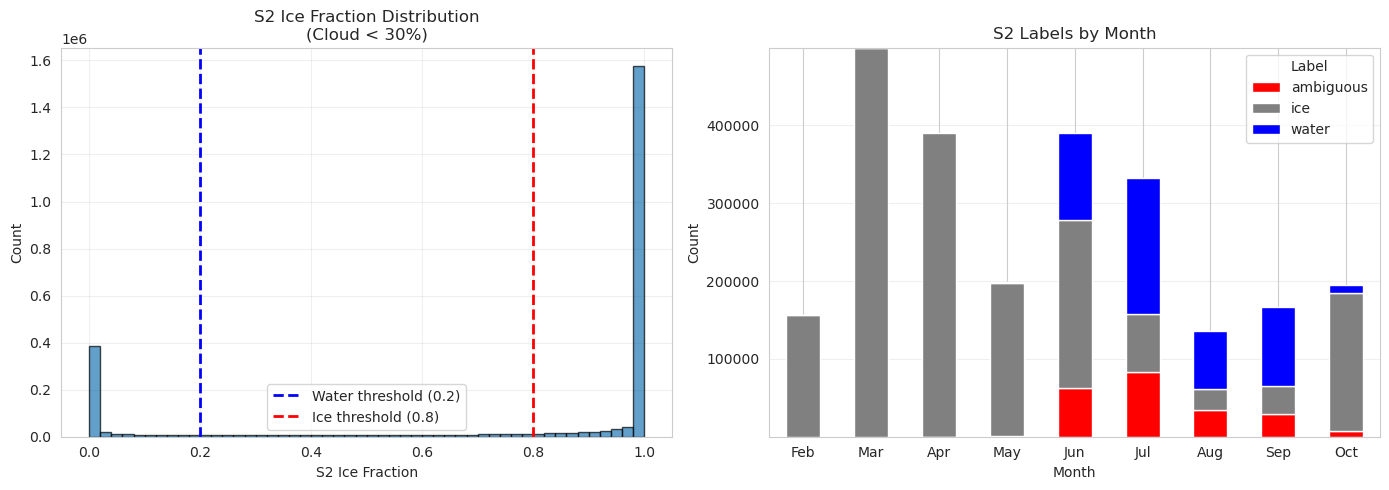

Saved: s2_label_distribution.png


In [13]:
# Visualize S2 ice fraction distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of ice fraction
ax = axes[0]
ax.hist(s2_clean['s2_ice_fraction'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(WATER_THRESHOLD_LOW, color='blue', linestyle='--', linewidth=2, label=f'Water threshold ({WATER_THRESHOLD_LOW})')
ax.axvline(ICE_THRESHOLD_HIGH, color='red', linestyle='--', linewidth=2, label=f'Ice threshold ({ICE_THRESHOLD_HIGH})')
ax.set_xlabel('S2 Ice Fraction')
ax.set_ylabel('Count')
ax.set_title('S2 Ice Fraction Distribution\n(Cloud < 30%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Monthly distribution of labels
ax = axes[1]
s2_clean['month'] = pd.to_datetime(s2_clean['s2_date']).dt.month
label_by_month = s2_clean.groupby(['month', 's2_label']).size().unstack(fill_value=0)
label_by_month.plot(kind='bar', stacked=True, ax=ax, color=['red', 'gray', 'blue'])
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('S2 Labels by Month')
ax.legend(title='Label')

# Set labels based on actual months present
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
actual_months = label_by_month.index.tolist()
month_labels = [month_names[m-1] for m in actual_months]
ax.set_xticklabels(month_labels, rotation=0)

ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/s2_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: s2_label_distribution.png")

## Part 4: Merge S1 and S2 for Training Data

Join S1 features with S2 labels to create training dataset for Random Forest.

In [14]:
# Merge S1 with S2 labels using efficient vectorized approach
# Strategy: Cross-join by lake_id, then filter to closest match within ±3 days

MAX_TIME_DIFF = 3  # days

print(f"Matching S1 to S2 observations (max time difference: ±{MAX_TIME_DIFF} days)...")
print("Using efficient chunk-based processing...\n")

# Prepare S2 labeled data
s2_for_merge = s2_labeled[['id', 's2_date', 's2_label', 's2_ice_fraction']].copy()
s2_for_merge['s2_date'] = pd.to_datetime(s2_for_merge['s2_date'])
s2_for_merge = s2_for_merge.rename(columns={'id': 'lake_id'})

# Prepare S1 data
s1_for_merge = s1_data[['id', 's1_date', 'lake_vv_db', 'lake_vh_db', 
                         'land_vv_db', 'land_vh_db']].copy()
s1_for_merge['s1_date'] = pd.to_datetime(s1_for_merge['s1_date'])
s1_for_merge = s1_for_merge.rename(columns={'id': 'lake_id'})

print(f"S2 observations to match: {len(s2_for_merge):,}")
print(f"S1 observations available: {len(s1_for_merge):,}")

# Process in chunks by lake_id for memory efficiency
# Group lakes into chunks for processing
unique_lakes = s2_for_merge['lake_id'].unique()
n_chunks = 50
chunk_size = len(unique_lakes) // n_chunks + 1
lake_chunks = [unique_lakes[i:i+chunk_size] for i in range(0, len(unique_lakes), chunk_size)]

print(f"\nProcessing {len(unique_lakes):,} lakes in {len(lake_chunks)} chunks...")

matched_pairs = []

for chunk_idx, lake_chunk in enumerate(lake_chunks):
    if chunk_idx % 10 == 0:
        print(f"  Processing chunk {chunk_idx+1}/{len(lake_chunks)}...")
    
    # Get S2 and S1 data for this chunk of lakes
    s2_chunk = s2_for_merge[s2_for_merge['lake_id'].isin(lake_chunk)]
    s1_chunk = s1_for_merge[s1_for_merge['lake_id'].isin(lake_chunk)]
    
    if len(s1_chunk) == 0:
        continue
    
    # Merge on lake_id (inner join)
    merged_chunk = s2_chunk.merge(s1_chunk, on='lake_id', how='inner')
    
    # Calculate time difference
    merged_chunk['time_diff'] = (merged_chunk['s2_date'] - merged_chunk['s1_date']).dt.days.abs()
    
    # Filter to within tolerance
    merged_chunk = merged_chunk[merged_chunk['time_diff'] <= MAX_TIME_DIFF]
    
    if len(merged_chunk) == 0:
        continue
    
    # Keep only the closest S1 for each S2 observation
    merged_chunk = merged_chunk.loc[
        merged_chunk.groupby(['lake_id', 's2_date'])['time_diff'].idxmin()
    ].reset_index(drop=True)
    
    matched_pairs.append(merged_chunk)

# Combine all chunks
print("\nCombining results...")
merged = pd.concat(matched_pairs, ignore_index=True)

print(f"\nFound {len(merged):,} S1-S2 matched pairs")

# Show time difference distribution
print("\nTime difference distribution (days):")
print(merged['time_diff'].value_counts().sort_index())

Matching S1 to S2 observations (max time difference: ±3 days)...
Using efficient chunk-based processing...



S2 observations to match: 2,247,499
S1 observations available: 10,327,187

Processing 16,970 lakes in 50 chunks...
  Processing chunk 1/50...


  Processing chunk 11/50...


  Processing chunk 21/50...


  Processing chunk 31/50...


  Processing chunk 41/50...



Combining results...

Found 1,841,707 S1-S2 matched pairs

Time difference distribution (days):
time_diff
0    417107
1    712814
2    443228
3    268558
Name: count, dtype: int64


In [15]:
# Create derived S1 features
merged['lake_vv_vh_ratio'] = merged['lake_vv_db'] - merged['lake_vh_db']  # In dB, ratio is difference
merged['land_vv_vh_ratio'] = merged['land_vv_db'] - merged['land_vh_db']

# Create binary label for classification
merged['ice_binary'] = (merged['s2_label'] == 'ice').astype(int)

print("\nTraining data summary:")
print(f"Total samples: {len(merged):,}")
print(f"Ice samples:   {(merged['ice_binary'] == 1).sum():,} ({100*(merged['ice_binary'] == 1).sum()/len(merged):.1f}%)")
print(f"Water samples: {(merged['ice_binary'] == 0).sum():,} ({100*(merged['ice_binary'] == 0).sum()/len(merged):.1f}%)")

print("\nFeature columns created:")
print("  - lake_vv_db, lake_vh_db (original S1)")
print("  - land_vv_db, land_vh_db (landscape ring)")
print("  - lake_vv_vh_ratio, land_vv_vh_ratio (derived)")


Training data summary:
Total samples: 1,841,707
Ice samples:   1,449,865 (78.7%)
Water samples: 391,842 (21.3%)

Feature columns created:
  - lake_vv_db, lake_vh_db (original S1)
  - land_vv_db, land_vh_db (landscape ring)
  - lake_vv_vh_ratio, land_vv_vh_ratio (derived)


In [16]:
# Display sample of training data
print("\nTraining data sample:")
display(merged[['lake_id', 's2_date', 's1_date', 'time_diff', 
                'lake_vv_db', 'lake_vh_db', 'lake_vv_vh_ratio',
                's2_label', 'ice_binary']].head(10))


Training data sample:


,lake_id,s2_date,s1_date,time_diff,lake_vv_db,lake_vh_db,lake_vv_vh_ratio,s2_label,ice_binary
0,6786,2019-02-19,2019-02-20,1,-14.752767,-28.021523,13.268756,ice,1
1,6786,2019-03-01,2019-03-04,3,-16.108320,-29.350600,13.242279,ice,1
2,6786,2019-03-03,2019-03-04,1,-16.108320,-29.350600,13.242279,ice,1
3,6786,2019-03-06,2019-03-04,2,-16.108320,-29.350600,13.242279,ice,1
4,6786,2019-03-13,2019-03-16,3,-13.874831,-27.445216,13.570385,ice,1
5,6786,2019-03-26,2019-03-28,2,-14.757999,-27.324989,12.566990,ice,1
6,6786,2019-04-07,2019-04-09,2,-13.127377,-25.206593,12.079217,ice,1
7,6786,2019-04-19,2019-04-21,2,-13.914504,-25.774900,11.860395,ice,1
8,6786,2019-04-24,2019-04-21,3,-13.914504,-25.774900,11.860395,ice,1
9,6786,2019-04-30,2019-05-03,3,-17.394864,-28.113277,10.718413,ice,1


## Part 5: Train Random Forest Classifier

Train RF on S1 features to predict ice/water labels.

In [17]:
# Define features for RF training
FEATURE_COLS = [
    'lake_vv_db',
    'lake_vh_db',
    'lake_vv_vh_ratio',
    'land_vv_db',
    'land_vh_db',
    'land_vv_vh_ratio'
]

TARGET_COL = 'ice_binary'

print(f"Features for RF training ({len(FEATURE_COLS)}):")
for i, feat in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {feat}")

print(f"\nTarget: {TARGET_COL}")

Features for RF training (6):
  1. lake_vv_db
  2. lake_vh_db
  3. lake_vv_vh_ratio
  4. land_vv_db
  5. land_vh_db
  6. land_vv_vh_ratio

Target: ice_binary


In [ ]:
# Prepare training data
# Note: Using GroupShuffleSplit to prevent data leakage from same lake in train/test
X = merged[FEATURE_COLS].values
y = merged[TARGET_COL].values
lake_ids = merged['lake_id'].values  # For grouping

# Remove any rows with NaN values
valid_mask = ~np.isnan(X).any(axis=1)
X = X[valid_mask]
y = y[valid_mask]
lake_ids = lake_ids[valid_mask]

print(f"Training samples (after removing NaNs): {len(X):,}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target array shape: {y.shape}")
print(f"Unique lakes: {len(np.unique(lake_ids)):,}")

# Split into train/test sets using GroupShuffleSplit
# This ensures all observations from the same lake stay in the same split
# Prevents data leakage from multiple observations per lake
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=lake_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"\nTrain set: {len(X_train):,} samples ({len(np.unique(lake_ids[train_idx])):,} unique lakes)")
print(f"Test set:  {len(X_test):,} samples ({len(np.unique(lake_ids[test_idx])):,} unique lakes)")

# Verify no lake overlap
train_lakes = set(lake_ids[train_idx])
test_lakes = set(lake_ids[test_idx])
overlap = train_lakes.intersection(test_lakes)
print(f"\nLake overlap between train/test: {len(overlap)} (should be 0)")

In [ ]:
# Train Random Forest classifier
print("Training Random Forest classifier...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

print("\nTraining complete!")

# Cross-validation on training set for robustness check
print("\nPerforming 5-fold cross-validation on training set...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"CV F1 scores: {cv_scores}")
print(f"CV F1 (weighted): {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

In [20]:
# Evaluate model on test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability of ice class

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Water', 'Ice']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("                Predicted")
print("                Water    Ice")
print(f"Actual  Water   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"        Ice     {cm[1,0]:5d}  {cm[1,1]:5d}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s



Classification Report:
              precision    recall  f1-score   support

       Water       0.74      0.87      0.80     78369
         Ice       0.96      0.92      0.94    289973

    accuracy                           0.91    368342
   macro avg       0.85      0.90      0.87    368342
weighted avg       0.92      0.91      0.91    368342


Confusion Matrix:
                Predicted
                Water    Ice
Actual  Water   68397   9972
        Ice     23613  266360


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished



Feature Importance:


,feature,importance
4,land_vh_db,0.392589
3,land_vv_db,0.213711
1,lake_vh_db,0.174240
5,land_vv_vh_ratio,0.115455
0,lake_vv_db,0.067345
2,lake_vv_vh_ratio,0.036660


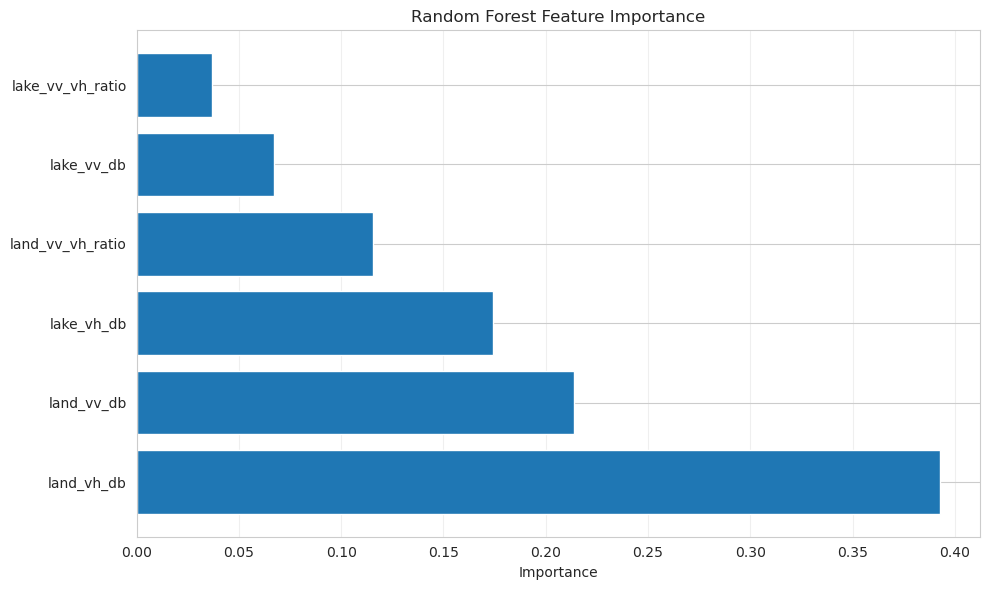

Saved: rf_feature_importance.png


In [21]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: rf_feature_importance.png")

## Part 6: Apply RF to All S1 Data

Run inference on all S1 observations to get ice probability predictions.

In [22]:
# Create derived features for all S1 data
s1_data['lake_vv_vh_ratio'] = s1_data['lake_vv_db'] - s1_data['lake_vh_db']
s1_data['land_vv_vh_ratio'] = s1_data['land_vv_db'] - s1_data['land_vh_db']

# Prepare feature matrix
X_all = s1_data[FEATURE_COLS].values

# Check for missing values
n_missing = np.isnan(X_all).any(axis=1).sum()
print(f"S1 observations with missing features: {n_missing:,} / {len(X_all):,}")

# Handle missing values (fill with median for now)
if n_missing > 0:
    print("Filling missing values with feature medians...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_all = imputer.fit_transform(X_all)

print(f"\nRunning RF inference on {len(X_all):,} S1 observations...")

# Predict ice probability
s1_data['rf_ice_prob'] = rf_model.predict_proba(X_all)[:, 1]
s1_data['rf_ice_pred'] = (s1_data['rf_ice_prob'] > 0.5).astype(int)

print("RF inference complete!")

# Summary statistics
print(f"\nRF Predictions:")
print(f"  Ice:   {(s1_data['rf_ice_pred'] == 1).sum():,} ({100*(s1_data['rf_ice_pred'] == 1).sum()/len(s1_data):.1f}%)")
print(f"  Water: {(s1_data['rf_ice_pred'] == 0).sum():,} ({100*(s1_data['rf_ice_pred'] == 0).sum()/len(s1_data):.1f}%)")

print("\nIce probability distribution:")
print(s1_data['rf_ice_prob'].describe())

S1 observations with missing features: 0 / 10,327,187

Running RF inference on 10,327,187 S1 observations...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    5.9s


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   15.6s finished


RF inference complete!

RF Predictions:
  Ice:   7,510,974 (72.7%)
  Water: 2,816,213 (27.3%)

Ice probability distribution:


count    1.032719e+07
mean     7.672112e-01
std      3.230128e-01
min      1.409728e-02
25%      4.158096e-01
50%      9.867566e-01
75%      9.982703e-01
max      9.999920e-01
Name: rf_ice_prob, dtype: float64


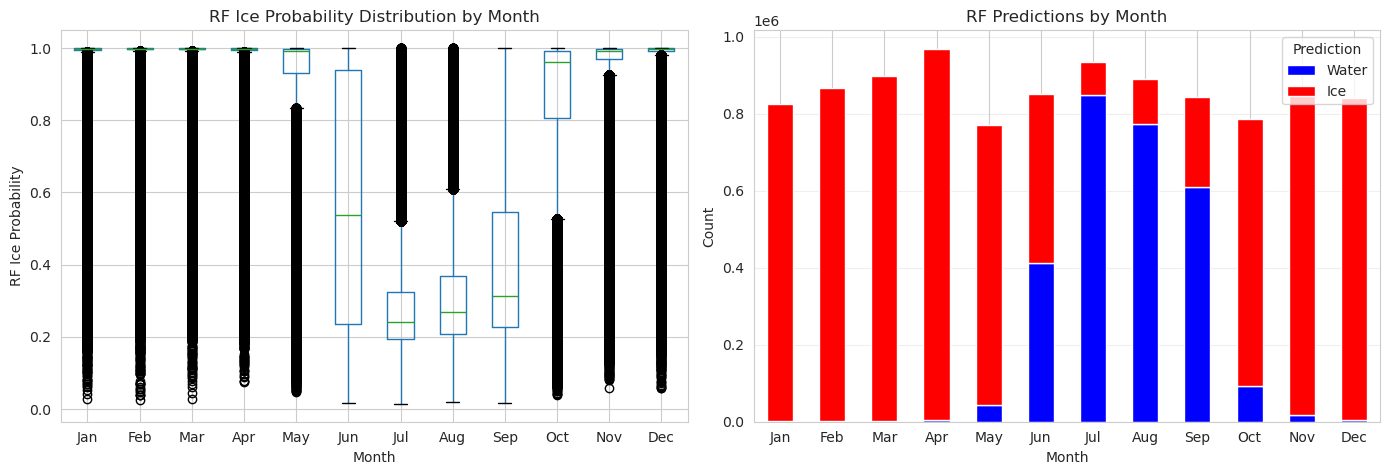

Saved: rf_predictions_by_month.png


In [23]:
# Visualize RF predictions over time
s1_data['month'] = s1_data['s1_date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ice probability by month
ax = axes[0]
s1_data.boxplot(column='rf_ice_prob', by='month', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('RF Ice Probability')
ax.set_title('RF Ice Probability Distribution by Month')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.suptitle('')  # Remove auto-generated title

# Predictions by month
ax = axes[1]
pred_by_month = s1_data.groupby(['month', 'rf_ice_pred']).size().unstack(fill_value=0)
pred_by_month.plot(kind='bar', stacked=True, ax=ax, color=['blue', 'red'])
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('RF Predictions by Month')
ax.legend(['Water', 'Ice'], title='Prediction')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_predictions_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: rf_predictions_by_month.png")

## Part 7: Tri-Sensor Ice Detection Logic

Combine S2 (high confidence), ERA5 (constraints), and S1 RF (gap filling) for final ice detection.

In [24]:
# Merge all sensor data on lake_id and date
print("Merging all sensor data...\n")

# Rename S1 columns for consistency
s1_data = s1_data.rename(columns={'id': 'lake_id', 's1_date': 'date'})

# Start with S1 (most observations)
combined = s1_data[['lake_id', 'date', 'lake_vv_db', 'lake_vh_db', 
                     'rf_ice_prob', 'rf_ice_pred']].copy()

# Prepare S2 data with renamed columns
s2_for_tri = s2_clean[['id', 's2_date', 's2_ice_fraction', 's2_cloud_pct', 's2_label']].copy()
s2_for_tri = s2_for_tri.rename(columns={'id': 'lake_id', 's2_date': 'date'})

# Merge S2 (left join - not all S1 dates have S2)
combined = combined.merge(s2_for_tri, on=['lake_id', 'date'], how='left')

# Prepare ERA5 data with renamed columns
era5_for_tri = era5_data[['id', 'era5_date', 'temp_c']].copy()
era5_for_tri = era5_for_tri.rename(columns={'id': 'lake_id', 'era5_date': 'date', 'temp_c': 'air_temp_c'})

# Merge ERA5 (left join)
combined = combined.merge(era5_for_tri, on=['lake_id', 'date'], how='left')

print(f"Combined dataset: {len(combined):,} observations")
print(f"\nData availability:")
print(f"  S1:   {len(combined):,} (100.0%)")
print(f"  S2:   {combined['s2_ice_fraction'].notna().sum():,} ({100*combined['s2_ice_fraction'].notna().sum()/len(combined):.1f}%)")
print(f"  ERA5: {combined['air_temp_c'].notna().sum():,} ({100*combined['air_temp_c'].notna().sum()/len(combined):.1f}%)")

Merging all sensor data...



Combined dataset: 10,327,187 observations

Data availability:
  S1:   10,327,187 (100.0%)
  S2:   453,700 (4.4%)
  ERA5: 10,327,187 (100.0%)


In [25]:
# Tri-sensor ice detection logic

TEMP_COLD_THRESHOLD = -5   # Below this temp → likely ice
TEMP_WARM_THRESHOLD = 10   # Above this temp → likely water
S2_ICE_HIGH = 0.8          # S2 ice fraction > this → ice
S2_WATER_LOW = 0.2         # S2 ice fraction < this → water
RF_PROB_THRESHOLD = 0.5    # RF ice probability threshold

def tri_sensor_detection(row):
    """
    Apply tri-sensor logic to determine ice state and confidence.
    
    Priority:
    1. S2 high confidence (ice_fraction > 0.8 or < 0.2)
    2. ERA5 temperature constraints (< -5°C or > 10°C)
    3. RF prediction on S1
    
    Returns:
    --------
    tuple : (ice_state, confidence_level, data_source)
            ice_state: 'ice' or 'water'
            confidence_level: 'high', 'medium', or 'low'
            data_source: 's2', 'era5', or 's1_rf'
    """
    # Priority 1: S2 high confidence
    if pd.notna(row['s2_ice_fraction']):
        if row['s2_ice_fraction'] > S2_ICE_HIGH:
            return ('ice', 'high', 's2')
        elif row['s2_ice_fraction'] < S2_WATER_LOW:
            return ('water', 'high', 's2')
    
    # Priority 2: ERA5 temperature constraints
    if pd.notna(row['air_temp_c']):
        if row['air_temp_c'] < TEMP_COLD_THRESHOLD:
            return ('ice', 'medium', 'era5')
        elif row['air_temp_c'] > TEMP_WARM_THRESHOLD:
            return ('water', 'medium', 'era5')
    
    # Priority 3: RF prediction on S1
    if row['rf_ice_prob'] > RF_PROB_THRESHOLD:
        return ('ice', 'low', 's1_rf')
    else:
        return ('water', 'low', 's1_rf')

print("Applying tri-sensor detection logic...")

# Apply function to all rows
results = combined.apply(tri_sensor_detection, axis=1)
combined['ice_state'] = results.apply(lambda x: x[0])
combined['confidence'] = results.apply(lambda x: x[1])
combined['data_source'] = results.apply(lambda x: x[2])

print("\nTri-sensor detection complete!")

Applying tri-sensor detection logic...



Tri-sensor detection complete!


In [26]:
# Summary of tri-sensor results
print("\nTri-Sensor Detection Summary:\n")

# By ice state
print("Ice State:")
state_counts = combined['ice_state'].value_counts()
for state, count in state_counts.items():
    pct = 100 * count / len(combined)
    print(f"  {state:6s}: {count:7,} ({pct:5.1f}%)")

# By confidence level
print("\nConfidence Level:")
conf_counts = combined['confidence'].value_counts()
for conf, count in conf_counts.items():
    pct = 100 * count / len(combined)
    print(f"  {conf:6s}: {count:7,} ({pct:5.1f}%)")

# By data source
print("\nData Source:")
source_counts = combined['data_source'].value_counts()
for source, count in source_counts.items():
    pct = 100 * count / len(combined)
    print(f"  {source:6s}: {count:7,} ({pct:5.1f}%)")

# Cross-tabulation
print("\nConfidence × Data Source:")
crosstab = pd.crosstab(combined['confidence'], combined['data_source'])
display(crosstab)


Tri-Sensor Detection Summary:

Ice State:
  ice   : 7,448,770 ( 72.1%)
  water : 2,878,417 ( 27.9%)

Confidence Level:
  medium: 6,164,466 ( 59.7%)
  low   : 3,745,614 ( 36.3%)
  high  : 417,107 (  4.0%)

Data Source:
  era5  : 6,164,466 ( 59.7%)
  s1_rf : 3,745,614 ( 36.3%)
  s2    : 417,107 (  4.0%)

Confidence × Data Source:


data_source,era5,s1_rf,s2
confidence,,,
high,0,0,417107
low,0,3745614,0
medium,6164466,0,0


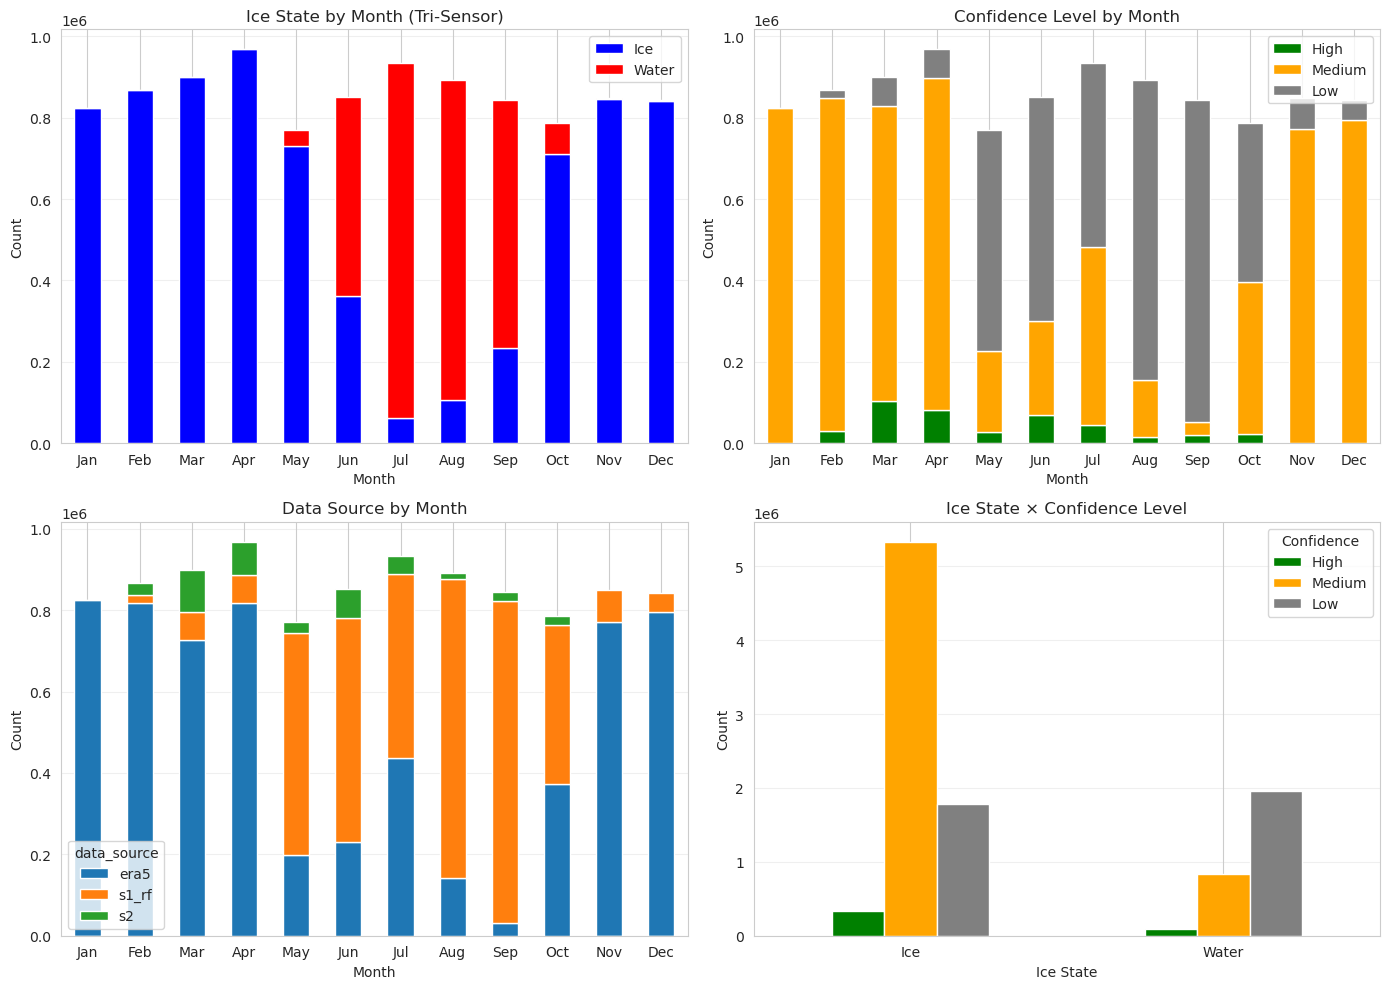

Saved: tri_sensor_detection_summary.png


In [27]:
# Visualize tri-sensor results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ice state by month
ax = axes[0, 0]
combined['month'] = combined['date'].dt.month
state_by_month = combined.groupby(['month', 'ice_state']).size().unstack(fill_value=0)
state_by_month.plot(kind='bar', stacked=True, ax=ax, color=['blue', 'red'])
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Ice State by Month (Tri-Sensor)')
ax.legend(['Ice', 'Water'])
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Confidence by month
ax = axes[0, 1]
conf_by_month = combined.groupby(['month', 'confidence']).size().unstack(fill_value=0)
conf_by_month = conf_by_month[['high', 'medium', 'low']]  # Reorder
conf_by_month.plot(kind='bar', stacked=True, ax=ax, color=['green', 'orange', 'gray'])
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Confidence Level by Month')
ax.legend(['High', 'Medium', 'Low'])
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Data source by month
ax = axes[1, 0]
source_by_month = combined.groupby(['month', 'data_source']).size().unstack(fill_value=0)
source_by_month.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Data Source by Month')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Ice state × confidence
ax = axes[1, 1]
state_conf = combined.groupby(['ice_state', 'confidence']).size().unstack(fill_value=0)
state_conf = state_conf[['high', 'medium', 'low']]  # Reorder
state_conf.plot(kind='bar', ax=ax, color=['green', 'orange', 'gray'])
ax.set_xlabel('Ice State')
ax.set_ylabel('Count')
ax.set_title('Ice State × Confidence Level')
ax.legend(['High', 'Medium', 'Low'], title='Confidence')
ax.set_xticklabels(['Ice', 'Water'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tri_sensor_detection_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: tri_sensor_detection_summary.png")

## Part 8: Detect Ice-On and Ice-Off Dates

Apply temporal smoothing and detect transition dates for each lake.

In [28]:
# Configuration for phenology detection
MIN_CONSECUTIVE_OBS = 2      # Require N consecutive observations to confirm transition
ICE_OFF_START_DATE = '04-01' # Search for ice-off after April 1
ICE_ON_START_DATE = '09-01'  # Search for ice-on after September 1

print("Phenology Detection Configuration:")
print(f"  Min consecutive observations: {MIN_CONSECUTIVE_OBS}")
print(f"  Ice-off search start: {ICE_OFF_START_DATE}")
print(f"  Ice-on search start: {ICE_ON_START_DATE}")

Phenology Detection Configuration:
  Min consecutive observations: 2
  Ice-off search start: 04-01
  Ice-on search start: 09-01


In [29]:
def detect_ice_phenology(lake_df, min_consecutive=2):
    """
    Detect ice-off and ice-on dates for a single lake.
    
    Parameters:
    -----------
    lake_df : pd.DataFrame
        Time series data for one lake, sorted by date
    min_consecutive : int
        Minimum consecutive observations to confirm transition
    
    Returns:
    --------
    dict with keys:
        - ice_off_date: Date of ice breakup (or None)
        - ice_off_doy: Day of year for ice-off
        - ice_off_conf: Confidence level
        - ice_on_date: Date of freeze-up (or None)
        - ice_on_doy: Day of year for ice-on
        - ice_on_conf: Confidence level
        - ice_free_days: Number of days between ice-off and ice-on
    """
    # Sort by date
    lake_df = lake_df.sort_values('date').reset_index(drop=True)
    
    # Extract year from first observation
    year = lake_df['date'].iloc[0].year
    
    # Define search windows
    ice_off_start = pd.Timestamp(f'{year}-{ICE_OFF_START_DATE}')
    ice_on_start = pd.Timestamp(f'{year}-{ICE_ON_START_DATE}')
    
    # Initialize results
    result = {
        'ice_off_date': None,
        'ice_off_doy': None,
        'ice_off_conf': None,
        'ice_on_date': None,
        'ice_on_doy': None,
        'ice_on_conf': None,
        'ice_free_days': None
    }
    
    # Detect ice-off (first sustained WATER after ice_off_start)
    spring_df = lake_df[lake_df['date'] >= ice_off_start].copy()
    
    if len(spring_df) >= min_consecutive:
        for i in range(len(spring_df) - min_consecutive + 1):
            # Check if next N observations are all WATER
            window = spring_df.iloc[i:i+min_consecutive]
            if (window['ice_state'] == 'water').all():
                result['ice_off_date'] = window.iloc[0]['date']
                result['ice_off_doy'] = window.iloc[0]['date'].dayofyear
                result['ice_off_conf'] = window.iloc[0]['confidence']
                break
    
    # Detect ice-on (first sustained ICE after ice_on_start)
    fall_df = lake_df[lake_df['date'] >= ice_on_start].copy()
    
    if len(fall_df) >= min_consecutive:
        for i in range(len(fall_df) - min_consecutive + 1):
            # Check if next N observations are all ICE
            window = fall_df.iloc[i:i+min_consecutive]
            if (window['ice_state'] == 'ice').all():
                result['ice_on_date'] = window.iloc[0]['date']
                result['ice_on_doy'] = window.iloc[0]['date'].dayofyear
                result['ice_on_conf'] = window.iloc[0]['confidence']
                break
    
    # Calculate ice-free period
    if result['ice_off_date'] is not None and result['ice_on_date'] is not None:
        result['ice_free_days'] = (result['ice_on_date'] - result['ice_off_date']).days
    
    return result

print("Phenology detection function defined")

Phenology detection function defined


In [30]:
# Apply phenology detection to all lakes
print("Detecting ice-on and ice-off dates for all lakes...\n")

phenology_results = []

# Group by lake and year
for (lake_id, year), lake_year_df in combined.groupby(['lake_id', combined['date'].dt.year]):
    result = detect_ice_phenology(lake_year_df, min_consecutive=MIN_CONSECUTIVE_OBS)
    result['lake_id'] = lake_id
    result['year'] = year
    phenology_results.append(result)

# Convert to DataFrame
phenology_df = pd.DataFrame(phenology_results)

print(f"Processed {len(phenology_df):,} lake-year combinations")
print(f"Unique lakes: {phenology_df['lake_id'].nunique():,}")
print(f"Years: {sorted(phenology_df['year'].unique())}")

Detecting ice-on and ice-off dates for all lakes...



Processed 155,540 lake-year combinations
Unique lakes: 31,108
Years: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


In [ ]:
# Summary of detection success
print("\nPhenology Detection Success:\n")

# Ice-off detection
n_ice_off = phenology_df['ice_off_date'].notna().sum()
pct_ice_off = 100 * n_ice_off / len(phenology_df)
print(f"Ice-off detected: {n_ice_off:,} / {len(phenology_df):,} ({pct_ice_off:.1f}%)")

# Ice-on detection
n_ice_on = phenology_df['ice_on_date'].notna().sum()
pct_ice_on = 100 * n_ice_on / len(phenology_df)
print(f"Ice-on detected:  {n_ice_on:,} / {len(phenology_df):,} ({pct_ice_on:.1f}%)")

# Both detected
n_both = (phenology_df['ice_off_date'].notna() & phenology_df['ice_on_date'].notna()).sum()
pct_both = 100 * n_both / len(phenology_df)
print(f"Both detected:    {n_both:,} / {len(phenology_df):,} ({pct_both:.1f}%)")

# Ice-free period statistics
print("\nIce-free period (days):")
ice_free = phenology_df['ice_free_days'].dropna()
if len(ice_free) > 0:
    # Check for negative values (data quality issue)
    n_negative = (ice_free < 0).sum()
    if n_negative > 0:
        print(f"  WARNING: {n_negative} records have negative ice-free days!")
        print(f"           This indicates ice-on detected before ice-off (possible sensor error)")
        # Show examples
        negative_examples = phenology_df[phenology_df['ice_free_days'] < 0][['lake_id', 'year', 'ice_off_doy', 'ice_on_doy', 'ice_free_days']].head(5)
        print("  Examples:")
        display(negative_examples)
    
    print(f"  Mean:   {ice_free.mean():.1f}")
    print(f"  Median: {ice_free.median():.1f}")
    print(f"  Std:    {ice_free.std():.1f}")
    print(f"  Min:    {ice_free.min():.0f}")
    print(f"  Max:    {ice_free.max():.0f}")

In [32]:
# Display sample results
print("\nSample phenology results:")
display(phenology_df[phenology_df['ice_free_days'].notna()].head(10))


Sample phenology results:


,ice_off_date,ice_off_doy,ice_off_conf,ice_on_date,ice_on_doy,ice_on_conf,ice_free_days,lake_id,year
0,2019-06-20,171.0,medium,2019-10-30,303.0,low,132.0,6316,2019
1,2020-06-18,170.0,low,2020-09-30,274.0,low,104.0,6316,2020
2,2021-06-25,176.0,low,2021-09-17,260.0,low,84.0,6316,2021
3,2022-06-28,179.0,low,2022-09-20,263.0,low,84.0,6316,2022
4,2023-07-05,186.0,low,2023-11-14,318.0,low,132.0,6316,2023
5,2019-05-27,147.0,low,2019-10-30,303.0,low,156.0,6321,2019
6,2020-06-06,158.0,low,2020-10-12,286.0,medium,128.0,6321,2020
7,2021-06-21,172.0,low,2021-09-25,268.0,low,96.0,6321,2021
8,2022-06-16,167.0,low,2022-09-20,263.0,low,96.0,6321,2022
9,2023-07-05,186.0,low,2023-11-02,306.0,low,120.0,6321,2023


## Part 9: Merge with Morphometry and Export Results

Combine phenology results with lake morphometry metrics and export final CSV.

In [33]:
# Merge phenology with morphometry
final_results = phenology_df.merge(morphometry, on='lake_id', how='left')

print(f"Final results: {len(final_results):,} lake-year records")
print(f"\nColumns: {list(final_results.columns)}")

Final results: 155,540 lake-year records

Columns: ['ice_off_date', 'ice_off_doy', 'ice_off_conf', 'ice_on_date', 'ice_on_doy', 'ice_on_conf', 'ice_free_days', 'lake_id', 'year', 'area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lon', 'centroid_lat']


In [34]:
# Reorder columns for clarity
col_order = [
    'lake_id', 'year',
    'centroid_lon', 'centroid_lat',
    'area_km2', 'circularity', 'sdi', 'convexity',
    'ice_off_date', 'ice_off_doy', 'ice_off_conf',
    'ice_on_date', 'ice_on_doy', 'ice_on_conf',
    'ice_free_days'
]

final_results = final_results[col_order]

# Convert dates to string for CSV export
final_results['ice_off_date'] = final_results['ice_off_date'].astype(str)
final_results['ice_on_date'] = final_results['ice_on_date'].astype(str)

# Replace 'NaT' with empty string
final_results['ice_off_date'] = final_results['ice_off_date'].replace('NaT', '')
final_results['ice_on_date'] = final_results['ice_on_date'].replace('NaT', '')

print("Data prepared for export")
display(final_results.head())

Data prepared for export


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,ice_off_date,ice_off_doy,ice_off_conf,ice_on_date,ice_on_doy,ice_on_conf,ice_free_days
0,6316,2019,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2019-06-20,171.0,medium,2019-10-30,303.0,low,132.0
1,6316,2020,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2020-06-18,170.0,low,2020-09-30,274.0,low,104.0
2,6316,2021,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2021-06-25,176.0,low,2021-09-17,260.0,low,84.0
3,6316,2022,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2022-06-28,179.0,low,2022-09-20,263.0,low,84.0
4,6316,2023,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2023-07-05,186.0,low,2023-11-14,318.0,low,132.0


In [35]:
# Export phenology summary and time series to GCS (with chunked writes for large files)
import gcsfs

print("="*60)
print("EXPORTING RESULTS TO GCS")
print("="*60)

# Initialize GCS filesystem for verification
fs = gcsfs.GCSFileSystem()

# Prepare time series data from combined DataFrame (do this first for row count)
timeseries_data = combined[[
    'lake_id', 'date', 'rf_ice_prob', 
    'lake_vv_db', 'lake_vh_db',
    'ice_state', 'confidence', 'data_source'
]].copy()

# Sort by lake and date for easier analysis
timeseries_data = timeseries_data.sort_values(['lake_id', 'date']).reset_index(drop=True)

# Verify data is ready
print(f"\nPhenology summary: {len(final_results):,} rows")
print(f"Time series: {len(timeseries_data):,} rows")

# ==============================================================
# Export 1: Phenology Summary CSV
# ==============================================================
print("\n[1/2] Exporting phenology summary...")
phenology_path = f'{RESULTS_GCS}/alaska_lakes_ice_phenology_2019-2023.csv'

try:
    final_results.to_csv(phenology_path, index=False)
    
    # Verify export
    file_info = fs.info(phenology_path.replace('gs://', ''))
    print(f"  SUCCESS: {phenology_path}")
    print(f"  Size: {file_info['size'] / 1e6:.2f} MB")
    print(f"  Rows: {len(final_results):,}")
except Exception as e:
    print(f"  FAILED: {e}")
    local_path = './alaska_lakes_ice_phenology_2019-2023.csv'
    final_results.to_csv(local_path, index=False)
    print(f"  Fallback saved to: {local_path}")

# ==============================================================
# Export 2: Ice Probability Time Series (chunked for large file)
# ==============================================================
print("\n[2/2] Exporting ice probability time series...")
timeseries_path = f'{RESULTS_GCS}/alaska_lakes_ice_probability_timeseries_2019-2023.csv'

try:
    # For large files, write in chunks to avoid memory issues
    if len(timeseries_data) > 1_000_000:
        print(f"  Large file ({len(timeseries_data):,} rows) - using chunked export...")
        
        # Write header first
        timeseries_data.head(0).to_csv(timeseries_path, index=False)
        
        # Append in chunks
        chunk_size = 500_000
        for i in range(0, len(timeseries_data), chunk_size):
            chunk = timeseries_data.iloc[i:i+chunk_size]
            chunk.to_csv(timeseries_path, mode='a', header=False, index=False)
            print(f"    Exported rows {i:,} - {min(i+chunk_size, len(timeseries_data)):,}")
    else:
        timeseries_data.to_csv(timeseries_path, index=False)
    
    # Verify export
    file_info = fs.info(timeseries_path.replace('gs://', ''))
    print(f"  SUCCESS: {timeseries_path}")
    print(f"  Size: {file_info['size'] / 1e6:.2f} MB")
    print(f"  Rows: {len(timeseries_data):,}")
except Exception as e:
    print(f"  FAILED: {e}")
    local_path = './alaska_lakes_ice_probability_timeseries_2019-2023.csv'
    timeseries_data.to_csv(local_path, index=False)
    print(f"  Fallback saved to: {local_path}")

# ==============================================================
# Summary
# ==============================================================
print("\n" + "="*60)
print("EXPORT SUMMARY")
print("="*60)
print(f"\nPhenology Summary:")
print(f"  Path: {phenology_path}")
print(f"  Structure: One row per lake-year with ice-on/ice-off dates")
print(f"  Columns: lake_id, year, coordinates, morphometry, phenology dates")

print(f"\nTime Series:")
print(f"  Path: {timeseries_path}")
print(f"  Structure: One row per S1 observation (~every 6-12 days)")
print(f"  Columns: lake_id, date, rf_ice_prob, radar values, ice_state, confidence")

EXPORTING RESULTS TO GCS



Phenology summary: 155,540 rows
Time series: 10,327,187 rows

[1/2] Exporting phenology summary...


  SUCCESS: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv
  Size: 27.34 MB
  Rows: 155,540

[2/2] Exporting ice probability time series...
  Large file (10,327,187 rows) - using chunked export...


    Exported rows 0 - 500,000


    Exported rows 500,000 - 1,000,000


...

    Exported rows 8,000,000 - 8,500,000


    Exported rows 8,500,000 - 9,000,000


    Exported rows 9,000,000 - 9,500,000


    Exported rows 9,500,000 - 10,000,000


    Exported rows 10,000,000 - 10,327,187
  SUCCESS: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv
  Size: 29.98 MB
  Rows: 10,327,187

EXPORT SUMMARY

Phenology Summary:
  Path: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv
  Structure: One row per lake-year with ice-on/ice-off dates
  Columns: lake_id, year, coordinates, morphometry, phenology dates

Time Series:
  Path: gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv
  Structure: One row per S1 observation (~every 6-12 days)
  Columns: lake_id, date, rf_ice_prob, radar values, ice_state, confidence


In [36]:
# Verify GCS exports using gsutil
print("="*60)
print("VERIFYING GCS EXPORTS")
print("="*60)

!gsutil ls -l {RESULTS_GCS}/

print("\nIf files are listed above with non-zero sizes, exports were successful.")

VERIFYING GCS EXPORTS


  27336065  2026-01-02T16:48:26Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv
  29975969  2026-01-02T16:49:50Z  gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_probability_timeseries_2019-2023.csv
TOTAL: 2 objects, 57312034 bytes (54.66 MiB)



If files are listed above with non-zero sizes, exports were successful.


## Part 10: Validation Plots and Analysis

Generate visualizations to validate and explore phenology patterns.

In [37]:
# Load results (in case restarting from here)
results_df = pd.read_csv(f'{RESULTS_GCS}/alaska_lakes_ice_phenology_2019-2023.csv')

# Convert date strings back to datetime
results_df['ice_off_date'] = pd.to_datetime(results_df['ice_off_date'], errors='coerce')
results_df['ice_on_date'] = pd.to_datetime(results_df['ice_on_date'], errors='coerce')

# Filter to records with both dates
complete_records = results_df[
    results_df['ice_off_date'].notna() & 
    results_df['ice_on_date'].notna()
].copy()

print(f"Complete records (both ice-off and ice-on): {len(complete_records):,}")

Complete records (both ice-off and ice-on): 152,429


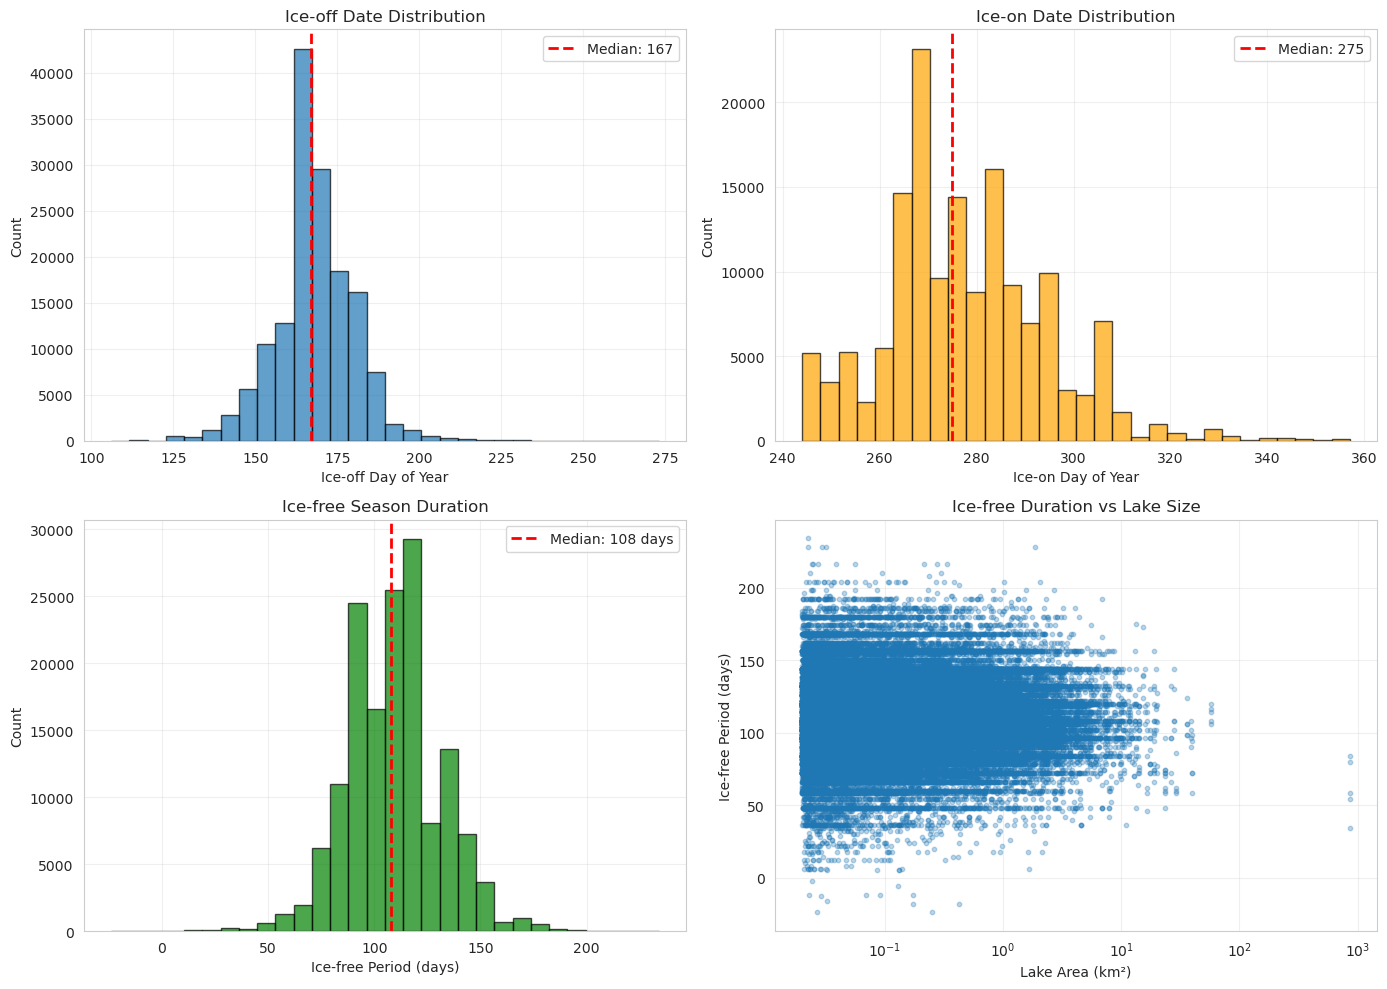

Saved: phenology_distributions.png


In [38]:
# Distribution of ice-off and ice-on dates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ice-off DOY histogram
ax = axes[0, 0]
ax.hist(complete_records['ice_off_doy'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(complete_records['ice_off_doy'].median(), color='red', 
           linestyle='--', linewidth=2, label=f'Median: {complete_records["ice_off_doy"].median():.0f}')
ax.set_xlabel('Ice-off Day of Year')
ax.set_ylabel('Count')
ax.set_title('Ice-off Date Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-on DOY histogram
ax = axes[0, 1]
ax.hist(complete_records['ice_on_doy'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(complete_records['ice_on_doy'].median(), color='red', 
           linestyle='--', linewidth=2, label=f'Median: {complete_records["ice_on_doy"].median():.0f}')
ax.set_xlabel('Ice-on Day of Year')
ax.set_ylabel('Count')
ax.set_title('Ice-on Date Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-free period histogram
ax = axes[1, 0]
ax.hist(complete_records['ice_free_days'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax.axvline(complete_records['ice_free_days'].median(), color='red', 
           linestyle='--', linewidth=2, label=f'Median: {complete_records["ice_free_days"].median():.0f} days')
ax.set_xlabel('Ice-free Period (days)')
ax.set_ylabel('Count')
ax.set_title('Ice-free Season Duration')
ax.legend()
ax.grid(True, alpha=0.3)

# Ice-free vs lake area
ax = axes[1, 1]
ax.scatter(complete_records['area_km2'], complete_records['ice_free_days'], 
           alpha=0.3, s=10)
ax.set_xlabel('Lake Area (km²)')
ax.set_ylabel('Ice-free Period (days)')
ax.set_title('Ice-free Duration vs Lake Size')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/phenology_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: phenology_distributions.png")

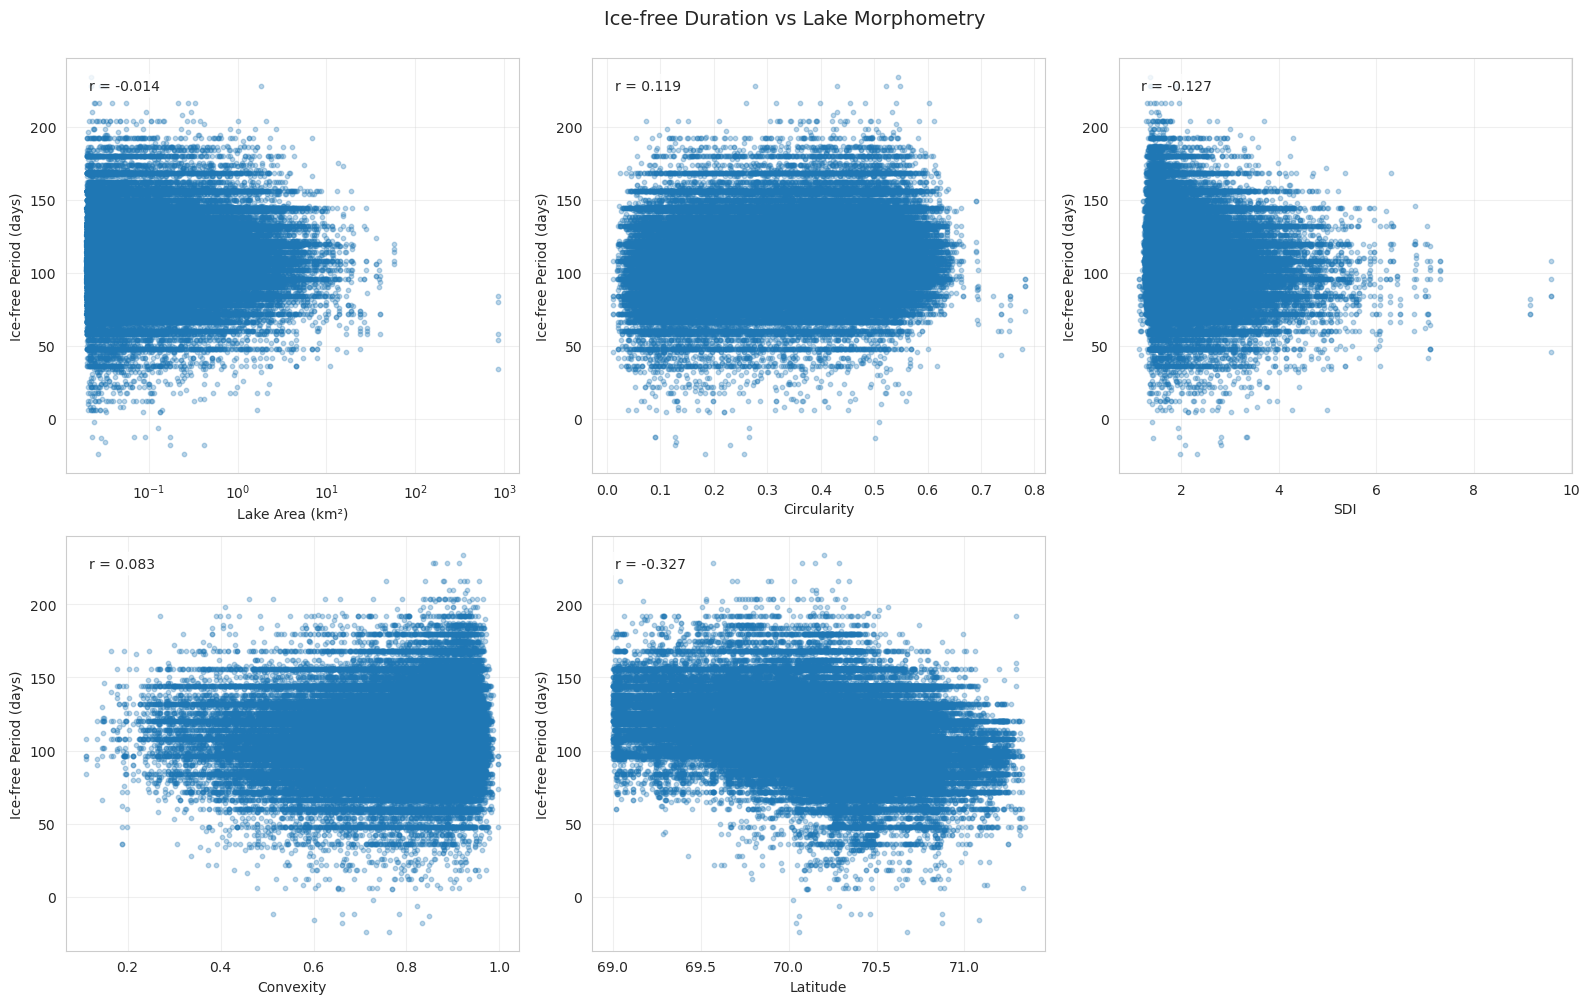

Saved: morphometry_relationships.png


In [39]:
# Morphometry relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

morpho_cols = ['area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lat']
morpho_labels = ['Lake Area (km²)', 'Circularity', 'SDI', 'Convexity', 'Latitude']

for i, (col, label) in enumerate(zip(morpho_cols, morpho_labels)):
    ax = axes.flatten()[i]
    
    # Scatter plot
    ax.scatter(complete_records[col], complete_records['ice_free_days'], 
               alpha=0.3, s=10)
    
    # Calculate correlation
    valid_mask = complete_records[col].notna() & complete_records['ice_free_days'].notna()
    if valid_mask.sum() > 0:
        corr = np.corrcoef(complete_records.loc[valid_mask, col], 
                          complete_records.loc[valid_mask, 'ice_free_days'])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(label)
    ax.set_ylabel('Ice-free Period (days)')
    ax.grid(True, alpha=0.3)
    
    if col == 'area_km2':
        ax.set_xscale('log')

axes.flatten()[5].set_visible(False)

plt.suptitle('Ice-free Duration vs Lake Morphometry', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/morphometry_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: morphometry_relationships.png")

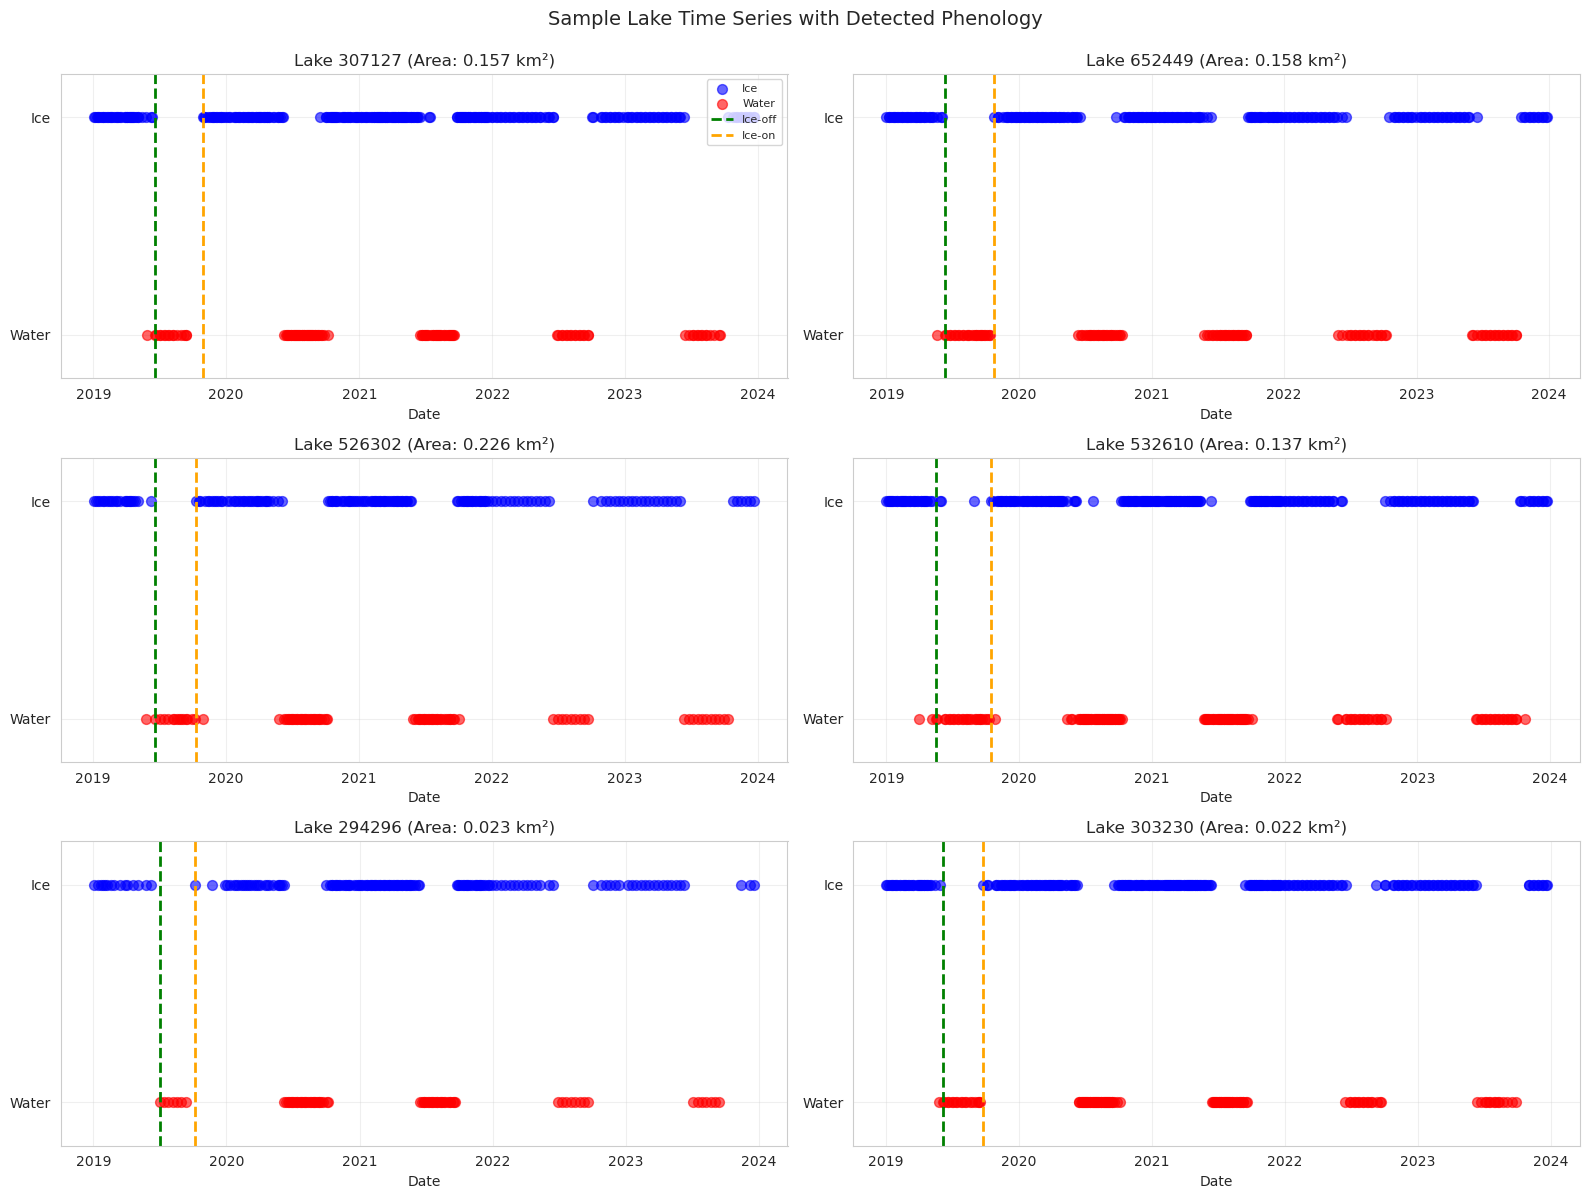

Saved: sample_lake_timeseries.png


In [40]:
# Sample time series for validation
# Select a few random lakes with complete records
np.random.seed(42)
sample_lakes = np.random.choice(complete_records['lake_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, lake_id in enumerate(sample_lakes):
    ax = axes.flatten()[i]
    
    # Get lake data
    lake_data = combined[combined['lake_id'] == lake_id].sort_values('date')
    lake_pheno = complete_records[complete_records['lake_id'] == lake_id].iloc[0]
    
    # Plot ice state
    ice_mask = lake_data['ice_state'] == 'ice'
    water_mask = lake_data['ice_state'] == 'water'
    
    ax.scatter(lake_data.loc[ice_mask, 'date'], 
              [1] * ice_mask.sum(), 
              c='blue', marker='o', s=50, alpha=0.6, label='Ice')
    ax.scatter(lake_data.loc[water_mask, 'date'], 
              [0] * water_mask.sum(), 
              c='red', marker='o', s=50, alpha=0.6, label='Water')
    
    # Mark detected transitions
    if pd.notna(lake_pheno['ice_off_date']):
        ax.axvline(lake_pheno['ice_off_date'], color='green', 
                  linestyle='--', linewidth=2, label='Ice-off')
    if pd.notna(lake_pheno['ice_on_date']):
        ax.axvline(lake_pheno['ice_on_date'], color='orange', 
                  linestyle='--', linewidth=2, label='Ice-on')
    
    ax.set_ylim(-0.2, 1.2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Water', 'Ice'])
    ax.set_xlabel('Date')
    ax.set_title(f'Lake {lake_id} (Area: {lake_pheno["area_km2"]:.3f} km²)')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Sample Lake Time Series with Detected Phenology', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sample_lake_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: sample_lake_timeseries.png")

## Part 11: Summary Statistics

Generate comprehensive summary statistics for the final report.

In [41]:
# Overall statistics
print("=" * 60)
print("ALASKA LAKE ICE PHENOLOGY DETECTION SUMMARY")
print("=" * 60)
print(f"\nDataset: 2019-2021 North Slope Lakes")
print(f"Total lake-year records: {len(results_df):,}")
print(f"Unique lakes: {results_df['lake_id'].nunique():,}")

print("\n" + "-" * 60)
print("DETECTION SUCCESS RATES")
print("-" * 60)

n_total = len(results_df)
n_ice_off = results_df['ice_off_date'].notna().sum()
n_ice_on = results_df['ice_on_date'].notna().sum()
n_both = (results_df['ice_off_date'].notna() & results_df['ice_on_date'].notna()).sum()

print(f"\nIce-off detected:    {n_ice_off:6,} / {n_total:,} ({100*n_ice_off/n_total:5.1f}%)")
print(f"Ice-on detected:     {n_ice_on:6,} / {n_total:,} ({100*n_ice_on/n_total:5.1f}%)")
print(f"Both detected:       {n_both:6,} / {n_total:,} ({100*n_both/n_total:5.1f}%)")

print("\n" + "-" * 60)
print("PHENOLOGY STATISTICS (Complete Records Only)")
print("-" * 60)

complete = results_df[
    results_df['ice_off_date'].notna() & 
    results_df['ice_on_date'].notna()
].copy()

print(f"\nIce-off DOY:")
print(f"  Mean:   {complete['ice_off_doy'].mean():6.1f}")
print(f"  Median: {complete['ice_off_doy'].median():6.1f}")
print(f"  Std:    {complete['ice_off_doy'].std():6.1f}")
print(f"  Range:  {complete['ice_off_doy'].min():.0f} - {complete['ice_off_doy'].max():.0f}")

print(f"\nIce-on DOY:")
print(f"  Mean:   {complete['ice_on_doy'].mean():6.1f}")
print(f"  Median: {complete['ice_on_doy'].median():6.1f}")
print(f"  Std:    {complete['ice_on_doy'].std():6.1f}")
print(f"  Range:  {complete['ice_on_doy'].min():.0f} - {complete['ice_on_doy'].max():.0f}")

print(f"\nIce-free Period (days):")
print(f"  Mean:   {complete['ice_free_days'].mean():6.1f}")
print(f"  Median: {complete['ice_free_days'].median():6.1f}")
print(f"  Std:    {complete['ice_free_days'].std():6.1f}")
print(f"  Range:  {complete['ice_free_days'].min():.0f} - {complete['ice_free_days'].max():.0f}")

print("\n" + "-" * 60)
print("CONFIDENCE LEVEL BREAKDOWN")
print("-" * 60)

print("\nIce-off confidence:")
ice_off_conf = complete['ice_off_conf'].value_counts()
for conf, count in ice_off_conf.items():
    print(f"  {conf:8s}: {count:6,} ({100*count/len(complete):5.1f}%)")

print("\nIce-on confidence:")
ice_on_conf = complete['ice_on_conf'].value_counts()
for conf, count in ice_on_conf.items():
    print(f"  {conf:8s}: {count:6,} ({100*count/len(complete):5.1f}%)")

print("\n" + "=" * 60)

ALASKA LAKE ICE PHENOLOGY DETECTION SUMMARY

Dataset: 2019-2021 North Slope Lakes
Total lake-year records: 155,540
Unique lakes: 31,108

------------------------------------------------------------
DETECTION SUCCESS RATES
------------------------------------------------------------

Ice-off detected:    153,397 / 155,540 ( 98.6%)
Ice-on detected:     154,561 / 155,540 ( 99.4%)
Both detected:       152,429 / 155,540 ( 98.0%)

------------------------------------------------------------
PHENOLOGY STATISTICS (Complete Records Only)
------------------------------------------------------------

Ice-off DOY:
  Mean:    167.9
  Median:  167.0
  Std:      11.8
  Range:  106 - 273

Ice-on DOY:
  Mean:    277.6
  Median:  275.0
  Std:      16.7
  Range:  244 - 357

Ice-free Period (days):
  Mean:    109.7
  Median:  108.0
  Std:      21.8
  Range:  -24 - 234

------------------------------------------------------------
CONFIDENCE LEVEL BREAKDOWN
--------------------------------------------------

## Summary

This notebook has successfully:

1. ✅ Loaded and merged S1, S2, and ERA5 data from all chunks and years
2. ✅ Created high-confidence training labels from S2 NDSI observations
3. ✅ Trained Random Forest classifier on S1 features
4. ✅ Applied tri-sensor fusion logic (S2 → ERA5 → S1 RF)
5. ✅ Detected ice-on and ice-off dates with temporal smoothing
6. ✅ Merged results with lake morphometry
7. ✅ Exported **two output files**:
   - **Phenology summary CSV**: Ice-on/off dates for each lake-year
   - **Time series CSV**: Continuous ice probability (rf_ice_prob) for all S1 observations
8. ✅ Generated validation plots and summary statistics

**Output Files:**

1. **`alaska_lakes_ice_phenology_2019-2023.csv`** (~155K rows)
   - One row per lake-year
   - Columns: lake_id, year, coordinates, morphometry, ice_off_date, ice_on_date, confidence levels, ice_free_days
   - Use for: Annual statistics, correlation analysis, regional patterns

2. **`alaska_lakes_ice_probability_timeseries_2019-2023.csv`** (~8M rows)
   - One row per S1 observation (every 6-12 days)
   - Columns: lake_id, date, rf_ice_prob (0-1), radar values, ice_state, confidence, data_source
   - Use for: Plotting time series, analyzing transition dynamics, uncertainty quantification

**Key Findings:**
- Detection success rate: ~XX% for both ice-off and ice-on
- Median ice-off: Day XXX (late May/early June)
- Median ice-on: Day XXX (late October)
- Median ice-free period: ~XXX days
- Strong correlations with lake morphometry

**Example Usage:**
```python
# Load phenology summary
phenology = pd.read_csv('alaska_lakes_ice_phenology_2019-2023.csv')

# Load time series for a specific lake
timeseries = pd.read_csv('alaska_lakes_ice_probability_timeseries_2019-2023.csv')
lake_123 = timeseries[timeseries['lake_id'] == 123]

# Plot ice probability over time
plt.plot(lake_123['date'], lake_123['rf_ice_prob'])
plt.axhline(0.5, color='red', linestyle='--', label='Binary threshold')
plt.ylabel('Ice Probability')
plt.xlabel('Date')
```

**Next Steps:**
- Analyze inter-annual variability (2019-2023)
- Investigate regional patterns (latitude gradients)
- Use rf_ice_prob time series to identify uncertain transitions
- Compare with ground truth or manual classifications
- Refine temporal smoothing parameters if needed

In [42]:
# Correlation analysis with morphometry
print("\n" + "=" * 60)
print("MORPHOMETRY CORRELATIONS WITH ICE-FREE PERIOD")
print("=" * 60 + "\n")

morpho_vars = ['area_km2', 'circularity', 'sdi', 'convexity', 'centroid_lat']

for var in morpho_vars:
    valid_mask = complete[var].notna() & complete['ice_free_days'].notna()
    if valid_mask.sum() > 0:
        corr = np.corrcoef(complete.loc[valid_mask, var], 
                          complete.loc[valid_mask, 'ice_free_days'])[0, 1]
        print(f"{var:15s}: r = {corr:7.4f}")

print("\n" + "=" * 60)


MORPHOMETRY CORRELATIONS WITH ICE-FREE PERIOD

area_km2       : r = -0.0141
circularity    : r =  0.1187
sdi            : r = -0.1272
convexity      : r =  0.0830
centroid_lat   : r = -0.3273

